# Ticker -> Quotes -> CaNN -> Comparison

1. descargar chain de opciones por API para un ticker
2. construir columnas necesarias para el pipeline (m, ta, r, iv, weight)
3. seleccionar un grid de N (default 35)
4. guardar un csv en 'data/market'
5. lanzar CaNN con varios resets y seleccionar el mejor (según el valor de la loss)
6. evaluer el Hessian en theta_star 


- El tipo libre de riesgo se obtiene de FRED (`DGS3MO`) 


In [70]:
from __future__ import annotations

from pathlib import Path
import os
import re
import sys
import json
import math
import subprocess
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from scipy.optimize import brentq


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'configs' / 'calibration.yaml').exists() and (candidate / 'scripts' / 'calibrate_cann.py').exists():
            return candidate
    raise FileNotFoundError('Root not found')


PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.solvers.bs import BS_solver

print(f'PROJECT_ROOT={PROJECT_ROOT}')
print(f'PYTHON={sys.executable}')


PROJECT_ROOT=/Users/jenriquezafra/Proyectos/Dev/python/TFM/TFM
PYTHON=/Users/jenriquezafra/Proyectos/Dev/python/TFM/TFM/.venv/bin/python


## Config

In [71]:
SYMBOL = 'MCD'
OPTION_SIDE = 'call'  # 'call' o 'put'
MODEL_DIR = 'Liu_like_v01'

TARGET_QUOTES = 35
MONEYNESS_RANGE = (0.80, 1.20)
TAU_RANGE_YEARS = (14 / 365, 2.0)  # minimo 14 dias, max 2 anos
MAX_SPREAD_PCT = 0.35

# Paginacion Nasdaq para incluir expiraciones largas.
NASDAQ_OFFSETS = [0, 500, 1000]

# Seleccion balanceada por buckets de tau.
TAU_BUCKET_EDGES = [14 / 365, 0.15, 0.35, 0.70, 1.20, 2.00]

# Recomendado para no introducir supuestos extra en la calibracion:
USE_UNIT_WEIGHTS = True

# Reinicios de calibracion para evitar quedar en soluciones "en borde" por azar.
N_CALIBRATION_RESTARTS = 8
BOUND_NEAR_REL_TOL = 0.01  # 1% del ancho del bound

MAXITER = 400
POPSIZE = 12

stamp = datetime.now().strftime('%Y%m%d')
OUTPUT_QUOTES_PATH = PROJECT_ROOT / 'data' / 'market' / f'market_quotes_{SYMBOL.lower()}_{stamp}.csv'

print('SYMBOL=', SYMBOL)
print('OUTPUT_QUOTES_PATH=', OUTPUT_QUOTES_PATH)
print('USE_UNIT_WEIGHTS=', USE_UNIT_WEIGHTS)
print('NASDAQ_OFFSETS=', NASDAQ_OFFSETS)
print('N_CALIBRATION_RESTARTS=', N_CALIBRATION_RESTARTS)


SYMBOL= MCD
OUTPUT_QUOTES_PATH= /Users/jenriquezafra/Proyectos/Dev/python/TFM/TFM/data/market/market_quotes_mcd_20260325.csv
USE_UNIT_WEIGHTS= True
NASDAQ_OFFSETS= [0, 500, 1000]
N_CALIBRATION_RESTARTS= 8


## 0. Some utilities

In [72]:
def _to_float(x) -> float:
    if x is None:
        return float('nan')
    s = str(x).strip()
    if s in {'', '--', 'N/A', 'NaN', 'nan', 'None'}:
        return float('nan')
    s = s.replace('$', '').replace(',', '')
    try:
        return float(s)
    except ValueError:
        return float('nan')


def _parse_spot_from_last_trade(last_trade_text: str) -> float:
    # Ejemplo: "LAST TRADE: $203.5 (AS OF MAR 24, 2026 12:29 PM ET)"
    m = re.search(r"\$\s*([0-9]+(?:\.[0-9]+)?)", str(last_trade_text))
    if not m:
        raise ValueError(f'No pude parsear spot desde lastTrade={last_trade_text!r}')
    return float(m.group(1))


def fetch_risk_free_rate_fred(default_rate: float = 0.03) -> float:
    # DGS3MO = 3-Month Treasury Constant Maturity Rate (percent)
    url = 'https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS3MO'
    try:
        df = pd.read_csv(url)
        series = pd.to_numeric(df['DGS3MO'], errors='coerce').dropna()
        if series.empty:
            return float(default_rate)
        return float(series.iloc[-1]) / 100.0
    except Exception:
        return float(default_rate)


def fetch_nasdaq_option_chain_paginated(symbol: str, *, offsets: list[int]) -> dict:
    symbol_u = symbol.upper()
    headers = {
        'User-Agent': 'Mozilla/5.0',
        'Accept': 'application/json, text/plain, */*',
        'Origin': 'https://www.nasdaq.com',
        'Referer': f'https://www.nasdaq.com/market-activity/stocks/{symbol.lower()}/option-chain',
    }

    merged_rows: list[dict] = []
    last_trade_text: str | None = None

    for off in offsets:
        url = (
            f'https://api.nasdaq.com/api/quote/{symbol_u}/option-chain?'
            f'assetclass=stocks&fromdate=all&limit=500&offset={int(off)}'
        )
        resp = requests.get(url, headers=headers, timeout=30)
        resp.raise_for_status()
        payload = resp.json()
        data = payload.get('data') or {}

        if data.get('lastTrade'):
            last_trade_text = data.get('lastTrade')

        rows = (data.get('table') or {}).get('rows') or []
        merged_rows.extend(rows)

    if not merged_rows:
        raise RuntimeError('No se recibieron filas de Nasdaq.')

    return {
        'lastTrade': last_trade_text,
        'table': {'rows': merged_rows},
    }


def parse_nasdaq_rows_to_candidates(chain_data: dict, *, option_side: str, trade_date) -> pd.DataFrame:
    rows = chain_data['table']['rows']
    spot = _parse_spot_from_last_trade(chain_data.get('lastTrade', ''))

    if option_side not in {'call', 'put'}:
        raise ValueError("option_side debe ser 'call' o 'put'.")

    bid_col = 'c_Bid' if option_side == 'call' else 'p_Bid'
    ask_col = 'c_Ask' if option_side == 'call' else 'p_Ask'
    vol_col = 'c_Volume' if option_side == 'call' else 'p_Volume'
    oi_col = 'c_Openinterest' if option_side == 'call' else 'p_Openinterest'

    parsed = []
    current_expiry = None

    for row in rows:
        expiry_group = (row.get('expirygroup') or '').strip()
        if expiry_group:
            # Fila cabecera, ej: "March 27, 2026"
            try:
                current_expiry = datetime.strptime(expiry_group, '%B %d, %Y').date()
            except ValueError:
                current_expiry = None
            continue

        if current_expiry is None:
            continue

        strike = _to_float(row.get('strike'))
        bid = _to_float(row.get(bid_col))
        ask = _to_float(row.get(ask_col))
        volume = _to_float(row.get(vol_col))
        open_interest = _to_float(row.get(oi_col))

        if not np.isfinite(strike) or not np.isfinite(bid) or not np.isfinite(ask):
            continue
        if ask <= 0 or bid < 0 or ask < bid:
            continue

        tau = (current_expiry - trade_date).days / 365.0
        if tau <= 0:
            continue

        mid = 0.5 * (bid + ask)
        moneyness = spot / strike
        spread_pct = (ask - bid) / max(mid, 1e-12)

        parsed.append(
            {
                'expiry': current_expiry,
                'strike': strike,
                'bid': bid,
                'ask': ask,
                'mid': mid,
                'tau': tau,
                'moneyness': moneyness,
                'volume': 0.0 if not np.isfinite(volume) else max(volume, 0.0),
                'open_interest': 0.0 if not np.isfinite(open_interest) else max(open_interest, 0.0),
                'spread_pct': spread_pct,
            }
        )

    out = pd.DataFrame(parsed)
    if out.empty:
        raise RuntimeError('No se obtuvieron filas validas de la API.')

    out = out.drop_duplicates(subset=['expiry', 'strike'], keep='first')
    out = out.sort_values(['expiry', 'strike']).reset_index(drop=True)
    out.attrs['spot'] = spot
    return out


## 1. Descarga de datos

In [73]:
trade_date = datetime.now(timezone.utc).date()

chain_data = fetch_nasdaq_option_chain_paginated(SYMBOL, offsets=NASDAQ_OFFSETS)
candidates = parse_nasdaq_rows_to_candidates(chain_data, option_side=OPTION_SIDE, trade_date=trade_date)
spot = float(candidates.attrs['spot'])
r = fetch_risk_free_rate_fred(default_rate=0.03)

print(f'SYMBOL={SYMBOL} | spot={spot:.4f} | r={r:.4%}')
print('en crudos:', len(candidates))

filtered = candidates.copy()
filtered = filtered[(filtered['moneyness'] >= MONEYNESS_RANGE[0]) & (filtered['moneyness'] <= MONEYNESS_RANGE[1])]
filtered = filtered[(filtered['tau'] >= TAU_RANGE_YEARS[0]) & (filtered['tau'] <= TAU_RANGE_YEARS[1])]
filtered = filtered[(filtered['spread_pct'] >= 0.0) & (filtered['spread_pct'] <= MAX_SPREAD_PCT)]
filtered = filtered[filtered['mid'] > 0.0].copy()

print('tras filtros de rango/spread:', len(filtered))
print('tau min/max:', filtered['tau'].min(), filtered['tau'].max())
print('tau unique:', filtered['tau'].nunique())
filtered.head()


SYMBOL=MCD | spot=312.2200 | r=3.7400%
en crudos: 693
tras filtros de rango/spread: 234
tau min/max: 0.043835616438356165 1.8273972602739725
tau unique: 14


,expiry,strike,bid,ask,mid,tau,moneyness,volume,open_interest,spread_pct
100,2026-04-10,265.0,46.00,48.90,47.450,0.043836,1.178189,0.0,0.0,0.061117
101,2026-04-10,270.0,41.05,44.10,42.575,0.043836,1.156370,0.0,0.0,0.071638
102,2026-04-10,275.0,36.20,39.20,37.700,0.043836,1.135345,0.0,0.0,0.079576
103,2026-04-10,280.0,31.75,34.25,33.000,0.043836,1.115071,0.0,0.0,0.075758
104,2026-04-10,285.0,26.45,29.35,27.900,0.043836,1.095509,0.0,0.0,0.103943


## 2. Get the IV from the market (Brent)

In [74]:
def implied_vol_from_market_price_bs(
    *,
    price: float,
    S0: float,
    K: float,
    tau: float,
    r: float,
    opt_type: str,
    sigma_low: float = 1e-6,
    sigma_high: float = 5.0,
) -> float:
    if not np.isfinite(price) or not np.isfinite(S0) or not np.isfinite(K) or not np.isfinite(tau) or tau <= 0:
        return float('nan')

    if opt_type == 'call':
        intrinsic = max(S0 - K * math.exp(-r * tau), 0.0)
        upper_bound = S0
    else:
        intrinsic = max(K * math.exp(-r * tau) - S0, 0.0)
        upper_bound = K * math.exp(-r * tau)

    if not (intrinsic < price < upper_bound):
        return float('nan')

    def f(sig):
        return BS_solver(S0=S0, K=K, tau=tau, sigma=sig, r=r, opt_type=opt_type) - price

    low = float(sigma_low)
    high = float(sigma_high)

    try:
        f_low = float(f(low))
        f_high = float(f(high))
    except Exception:
        return float('nan')

    tries = 0
    while f_low * f_high > 0 and high < 20.0 and tries < 6:
        high *= 2.0
        tries += 1
        try:
            f_high = float(f(high))
        except Exception:
            return float('nan')

    if f_low * f_high > 0:
        return float('nan')

    try:
        return float(brentq(f, low, high, xtol=1e-8, maxiter=300))
    except Exception:
        return float('nan')


iv_vals = [
    implied_vol_from_market_price_bs(
        price=float(mid),
        S0=spot,
        K=float(K),
        tau=float(tau),
        r=float(r),
        opt_type=OPTION_SIDE,
    )
    for mid, K, tau in zip(filtered['mid'], filtered['strike'], filtered['tau'])
]

filtered = filtered.copy()
filtered['iv_market'] = np.asarray(iv_vals, dtype=np.float64)
filtered = filtered[np.isfinite(filtered['iv_market'])]
filtered = filtered[(filtered['iv_market'] > 0.01) & (filtered['iv_market'] < 3.0)].copy()

print('con IV bien:', len(filtered))
filtered[['expiry', 'strike', 'moneyness', 'tau', 'mid', 'iv_market', 'spread_pct']].head()


con IV bien: 231


,expiry,strike,moneyness,tau,mid,iv_market,spread_pct
102,2026-04-10,275.0,1.135345,0.043836,37.700,0.245035,0.079576
103,2026-04-10,280.0,1.115071,0.043836,33.000,0.305348,0.075758
104,2026-04-10,285.0,1.095509,0.043836,27.900,0.245105,0.103943
105,2026-04-10,290.0,1.076621,0.043836,23.325,0.261211,0.139335
106,2026-04-10,295.0,1.058373,0.043836,18.725,0.247422,0.168224


## 3. Select `TARGET_QUOTES`, construir pesos y guardar CSV

In [75]:
work = filtered.copy()

# score de liquidez-calidad para priorizar quotes
liq_score = np.log1p(work['volume']) + 0.5 * np.log1p(work['open_interest'])
spread_pen = np.clip(work['spread_pct'], 0.0, 1.0)
work['score'] = liq_score - 2.0 * spread_pen

# seleccion balanceada por buckets de tau para evitar sesgo a vencimientos cortos
edges = list(TAU_BUCKET_EDGES)
labels = [f'B{i+1}' for i in range(len(edges) - 1)]
work['tau_bucket'] = pd.cut(work['tau'], bins=edges, labels=labels, include_lowest=True, right=True)

selected_parts = []
for b in labels:
    sb = work[work['tau_bucket'] == b].copy()

    target_bucket = max(4, TARGET_QUOTES // len(labels))

    q = int(min(7, max(2, sb['moneyness'].nunique())))
    sb['m_bin'] = pd.qcut(sb['moneyness'], q=q, duplicates='drop')

    base = sb.sort_values('score', ascending=False).groupby('m_bin', dropna=False, observed=False).head(1)
    sel = base.sort_values('score', ascending=False)

    if len(sel) < target_bucket:
        rem = sb.sort_values('score', ascending=False)
        rem = rem.loc[~rem.index.isin(sel.index)]
        sel = pd.concat([sel, rem.head(target_bucket - len(sel))], axis=0)
    elif len(sel) > target_bucket:
        sel = sel.head(target_bucket)

    selected_parts.append(sel)

if selected_parts:
    selected = pd.concat(selected_parts, axis=0)
else:
    selected = work.sort_values('score', ascending=False).head(TARGET_QUOTES)

if len(selected) < TARGET_QUOTES:
    remaining = work.sort_values('score', ascending=False)
    remaining = remaining.loc[~remaining.index.isin(selected.index)]
    selected = pd.concat([selected, remaining.head(TARGET_QUOTES - len(selected))], axis=0)
elif len(selected) > TARGET_QUOTES:
    selected = selected.sort_values('score', ascending=False).head(TARGET_QUOTES)

selected = selected.copy()
selected['r'] = float(r)

if USE_UNIT_WEIGHTS:
    selected['weight'] = 1.0
else:
    raw_weight = (1.0 / np.maximum(selected['spread_pct'], 1e-3)) * np.log1p(
        selected['open_interest'] + selected['volume'] + 1.0
    )
    mean_w = float(np.nanmean(raw_weight)) if np.isfinite(np.nanmean(raw_weight)) else 1.0
    selected['weight'] = raw_weight / max(mean_w, 1e-8)

quotes_df = (
    selected[['moneyness', 'tau', 'r', 'iv_market', 'weight']]
    .sort_values(['tau', 'moneyness'])
    .reset_index(drop=True)
)

OUTPUT_QUOTES_PATH.parent.mkdir(parents=True, exist_ok=True)
quotes_df.to_csv(OUTPUT_QUOTES_PATH, index=False)

print('quotes finales:', len(quotes_df))
print('guardado en:', OUTPUT_QUOTES_PATH)

quotes_df.head(10)


quotes finales: 35
guardado en: /Users/jenriquezafra/Proyectos/Dev/python/TFM/TFM/data/market/market_quotes_mcd_20260325.csv


,moneyness,tau,r,iv_market,weight
0,0.975688,0.063014,0.0374,0.189615,1.0
1,1.040733,0.063014,0.0374,0.207477,1.0
2,0.918294,0.139726,0.0374,0.210091,1.0
3,1.007161,0.139726,0.0374,0.229076,1.0
4,1.058373,0.139726,0.0374,0.240079,1.0
5,1.115071,0.139726,0.0374,0.280611,1.0
6,1.178189,0.139726,0.0374,0.313951,1.0
7,0.867278,0.232877,0.0374,0.191761,1.0
8,0.918294,0.232877,0.0374,0.190338,1.0
9,0.975688,0.232877,0.0374,0.200423,1.0


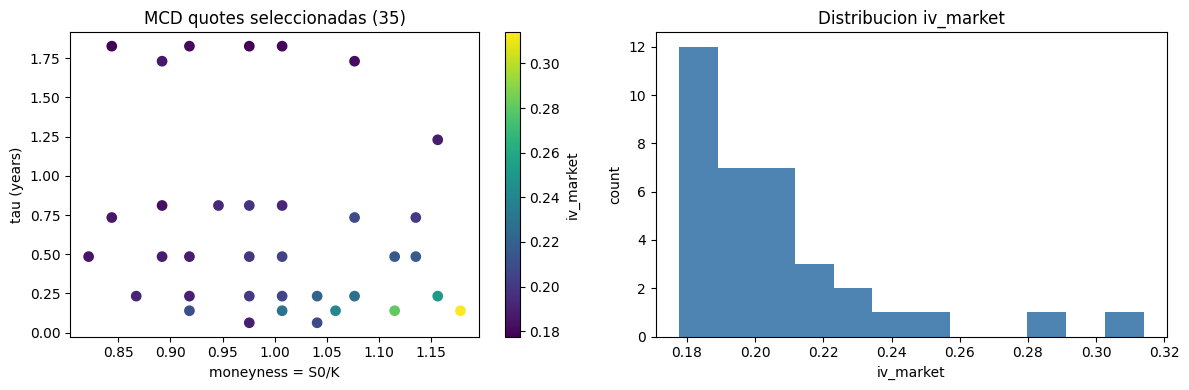

In [76]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sc = ax[0].scatter(quotes_df['moneyness'], quotes_df['tau'], c=quotes_df['iv_market'], cmap='viridis', s=45)
ax[0].set_title(f'{SYMBOL} quotes seleccionadas ({len(quotes_df)})')
ax[0].set_xlabel('moneyness = S0/K')
ax[0].set_ylabel('tau (years)')
fig.colorbar(sc, ax=ax[0], label='iv_market')

ax[1].hist(quotes_df['iv_market'], bins=12, color='#2E6EA5', alpha=0.85)
ax[1].set_title('Distribucion iv_market')
ax[1].set_xlabel('iv_market')
ax[1].set_ylabel('count')

fig.tight_layout()
plt.show()


## Ejecutar calibracion CaNN (con resets) y seleccionar mejor run



In [77]:
def _run(cmd: list[str]) -> str:
    proc = subprocess.run(cmd, cwd=PROJECT_ROOT, capture_output=True, text=True, check=False)
    if proc.returncode != 0:
        print(proc.stdout)
        print(proc.stderr)
        raise RuntimeError(f"Command failed ({proc.returncode}): {' '.join(cmd)}")
    return proc.stdout


def _read_json(path: Path) -> dict:
    with open(path, 'r') as f:
        return json.load(f)


def calibrate_once(quotes_path: Path) -> tuple[Path, dict]:
    cmd = [
        sys.executable,
        'scripts/calibrate_cann.py',
        '--config', 'configs/calibration.yaml',
        '--model-dir', MODEL_DIR,
        '--quotes', str(quotes_path),
        '--maxiter', str(int(MAXITER)),
        '--popsize', str(int(POPSIZE)),
    ]
    stdout = _run(cmd)
    m = re.search(r'Saved outputs to:\s*(.+)', stdout)
    if not m:
        raise RuntimeError('No pude detectar carpeta de salida en calibrate_cann stdout.')
    out_dir = Path(m.group(1).strip())
    return out_dir, _read_json(out_dir / 'summary.json')


def bounds_report(summary: dict, rel_tol: float) -> tuple[list[str], pd.DataFrame]:
    rows = []
    active = []
    for n, v in zip(summary['parameter_order'], summary['theta_star']):
        lo, hi = [float(x) for x in summary['bounds'][n]]
        v = float(v)
        rel = min(v - lo, hi - v) / max(hi - lo, 1e-12)
        near = bool(rel <= rel_tol)
        if near:
            active.append(n)
        rows.append({
            'parameter': n,
            'theta_hat': v,
            'lower': lo,
            'upper': hi,
            'rel_dist_to_nearest_bound': rel,
            'near_bound': near,
        })
    return active, pd.DataFrame(rows)



trials = []
for i in range(int(N_CALIBRATION_RESTARTS)):
    out_i, sum_i = calibrate_once(OUTPUT_QUOTES_PATH)
    active_i, _ = bounds_report(sum_i, BOUND_NEAR_REL_TOL)
    trials.append({
        'trial': i + 1,
        'output_dir': str(out_i),
        'objective_fun': float(sum_i.get('objective_fun', np.nan)),
        'weighted_mse': float(sum_i.get('weighted_mse', np.nan)),
        'residual_rmse': float(sum_i.get('residual_rmse', np.nan)),
        'n_active_bounds': int(len(active_i)),
        'active_bounds': ','.join(active_i),
    })
    print(f"[{i+1}/{N_CALIBRATION_RESTARTS}] objective={sum_i.get('objective_fun'):.8f} active_bounds={active_i} out={out_i.name}")

# criterio: primero menos parametros en borde, luego menor objetivo
trials_df = pd.DataFrame(trials).sort_values(['n_active_bounds', 'objective_fun'], ascending=[True, True]).reset_index(drop=True)
best_dir = Path(trials_df.iloc[0]['output_dir'])
summary = _read_json(best_dir / 'summary.json')

print('\nRanking de reinicios (mejor arriba):')
print(trials_df.to_string(index=False))

print('\nResumen calibracion seleccionada')
print('  output_dir   :', best_dir)
print('  success      :', summary.get('success'))
print('  objective_fun:', summary.get('objective_fun'))
print('  weighted_mse :', summary.get('weighted_mse'))
print('  residual_rmse:', summary.get('residual_rmse'))

print('\nTheta calibrada (corrida seleccionada)')
for name, value in zip(summary.get('parameter_order', []), summary.get('theta_star', [])):
    print(f'  {name:>6s} = {float(value): .8f}')

active_best, bounds_df = bounds_report(summary, BOUND_NEAR_REL_TOL)
print(f"\nBounds activos (tol={BOUND_NEAR_REL_TOL:.2%}):", active_best if active_best else 'ninguno')
print(bounds_df.to_string(index=False))




[1/8] objective=0.00798252 active_bounds=[] out=Calibration_2
[2/8] objective=0.00798842 active_bounds=['v0'] out=Calibration_3
[3/8] objective=0.00798342 active_bounds=[] out=Calibration_4
[4/8] objective=0.00798245 active_bounds=['v0'] out=Calibration_5
[5/8] objective=0.00797992 active_bounds=[] out=Calibration_6
[6/8] objective=0.00798178 active_bounds=['v0'] out=Calibration_7
[7/8] objective=0.00797870 active_bounds=['v0'] out=Calibration_8
[8/8] objective=0.00799853 active_bounds=['v0'] out=Calibration_9

Ranking de reinicios (mejor arriba):
 trial                                                                                       output_dir  objective_fun  weighted_mse  residual_rmse  n_active_bounds active_bounds
     5 /Users/jenriquezafra/Proyectos/Dev/python/TFM/TFM/outputs/calibration/Liu_like_v01/Calibration_6       0.007980      0.000228       0.015100                0              
     1 /Users/jenriquezafra/Proyectos/Dev/python/TFM/TFM/outputs/calibration/Liu_like_v0

## Nota

Si aun aparece algun parametro en borde, sube `N_CALIBRATION_RESTARTS` o ajusta filtros (`MONEYNESS_RANGE`, `TAU_RANGE_YEARS`, `MAX_SPREAD_PCT`).


## Simulacion de precio con Heston (Euler-Maruyama, horizonte 2 meses)

Usamos los parametros calibrados de CaNN (`theta_star`) y la discretizacion de Euler-Maruyama con truncacion para la varianza:
$$ dW_s = Z_1  \sqrt{dt} $$
$$ dW_v = (\rho  Z_1 + \sqrt{1-\rho^2} * Z_2)  \sqrt{dt} $$
$$ v_{t+dt} = v_t + \kappa  (\bar{v} - v_t)  dt + \gamma  \sqrt{max(v_t, 0)}  dW_v $$
$$ S_{t+dt} = S_t + r  S_t  dt + \sqrt{max(v_t, 0)}  S_t  dW_s $$


Horizon temporal fijado en 2 meses desde la fecha de calibracion.

In [78]:
# Parametros de Heston calibrados (orden CaNN: [rho, kappa, gamma, bar_v, v0]).
PARAM_ORDER_DEFAULT = ['rho', 'kappa', 'gamma', 'bar_v', 'v0']

if 'summary' not in globals():
    raise RuntimeError('No existe `summary` en memoria. Ejecuta antes la celda de calibracion CaNN.')

theta_star = np.asarray(summary.get('theta_star', []), dtype=np.float64).reshape(-1)
param_order = [str(x) for x in summary.get('parameter_order', PARAM_ORDER_DEFAULT)]
if theta_star.size != len(param_order):
    raise RuntimeError(
        f'`theta_star` y `parameter_order` no son compatibles: {theta_star.size} vs {len(param_order)}'
    )

theta_map = {name: float(value) for name, value in zip(param_order, theta_star)}
missing = [name for name in PARAM_ORDER_DEFAULT if name not in theta_map]
if missing:
    raise KeyError(f'Faltan parametros Heston en la calibracion: {missing}')

rho = float(theta_map['rho'])
kappa = float(theta_map['kappa'])
gamma = float(theta_map['gamma'])
bar_v = float(theta_map['bar_v'])
v0 = float(theta_map['v0'])

if 'spot' not in globals():
    raise RuntimeError('No existe `spot` en memoria. Ejecuta las celdas de descarga/parseo.')
S0 = float(spot)

if 'quotes_df' in globals() and not quotes_df.empty:
    r_heston = float(quotes_df['r'].iloc[0])
else:
    r_heston = float(r)

# Fijamos la fecha de calibracion/prediccion solicitada por el experimento.
CALIBRATION_DATE = pd.Timestamp('2026-01-01')
start_date = CALIBRATION_DATE.normalize()

horizon_months = 2
end_date_target = (start_date + pd.DateOffset(months=horizon_months)).normalize()
business_dates = pd.bdate_range(start=start_date, end=end_date_target, inclusive='both')
if len(business_dates) < 2:
    business_dates = pd.bdate_range(start=start_date, periods=2)

n_steps = int(len(business_dates) - 1)
T_years = float((end_date_target.date() - start_date.date()).days / 365.0)
if T_years <= 0.0:
    raise RuntimeError('Horizonte temporal invalido para simulacion.')

n_paths = 20_000
seed_em = 123

print('Parametros Heston usados:')
print(f'  rho={rho:.6f}, kappa={kappa:.6f}, gamma={gamma:.6f}, bar_v={bar_v:.6f}, v0={v0:.6f}')
print('Ventana temporal (fija):')
print(f'  inicio={start_date.date()} | fin_objetivo={end_date_target.date()} | dias_bursatiles={len(business_dates)}')
print('para Euler-Maruyama:')
print(f'  S0={S0:.6f}, r={r_heston:.6f}, T={T_years:.6f} anos, n_steps={n_steps}, n_paths={n_paths}, seed={seed_em}')

Parametros Heston usados:
  rho=-0.613654, kappa=2.666339, gamma=0.368655, bar_v=0.029485, v0=0.054693
Ventana temporal (fija):
  inicio=2026-01-01 | fin_objetivo=2026-03-01 | dias_bursatiles=42
para Euler-Maruyama:
  S0=312.220000, r=0.037400, T=0.161644 anos, n_steps=41, n_paths=20000, seed=123


In [79]:
def simulate_heston_euler_maruyama(
    *,
    S0: float,
    v0: float,
    r: float,
    rho: float,
    kappa: float,
    gamma: float,
    bar_v: float,
    T: float,
    n_steps: int,
    n_paths: int,
    seed: int = 123,
    n_store_paths: int = 0,
):
    rng = np.random.default_rng(seed)
    dt = float(T) / float(n_steps)
    sqrt_dt = math.sqrt(dt)

    s = np.full(n_paths, float(S0), dtype=np.float64)
    v = np.full(n_paths, float(v0), dtype=np.float64)
    mean_path = np.empty(n_steps + 1, dtype=np.float64)
    mean_path[0] = float(S0)

    n_store = int(max(0, min(n_store_paths, n_paths)))
    if n_store > 0:
        s_paths = np.empty((n_steps + 1, n_store), dtype=np.float64)
        v_paths = np.empty((n_steps + 1, n_store), dtype=np.float64)
        s_paths[0, :] = s[:n_store]
        v_paths[0, :] = v[:n_store]
    else:
        s_paths = None
        v_paths = None

    rho_safe = float(np.clip(rho, -0.999999, 0.999999))
    corr_scale = math.sqrt(max(1.0 - rho_safe**2, 0.0))

    for t in range(n_steps):
        z1 = rng.standard_normal(n_paths)
        z2 = rng.standard_normal(n_paths)

        dW_s = z1 * sqrt_dt
        dW_v = (rho_safe * z1 + corr_scale * z2) * sqrt_dt

        v_pos = np.maximum(v, 0.0)
        v_next = v + kappa * (bar_v - v) * dt + gamma * np.sqrt(v_pos) * dW_v
        v = np.maximum(v_next, 0.0)

        s = s + r * s * dt + np.sqrt(v_pos) * s * dW_s
        s = np.maximum(s, 1e-12)
        mean_path[t + 1] = float(np.mean(s))

        if n_store > 0:
            s_paths[t + 1, :] = s[:n_store]
            v_paths[t + 1, :] = v[:n_store]

    return s, v, s_paths, v_paths, mean_path

S_T, v_T, S_paths, v_paths, mc_mean_path = simulate_heston_euler_maruyama(
    S0=S0,
    v0=v0,
    r=r_heston,
    rho=rho,
    kappa=kappa,
    gamma=gamma,
    bar_v=bar_v,
    T=T_years,
    n_steps=n_steps,
    n_paths=n_paths,
    seed=seed_em,
    n_store_paths=50,
)

t_grid_years = np.linspace(0.0, T_years, n_steps + 1)
rn_mean_path = S0 * np.exp(r_heston * t_grid_years)
S_theoretical_rn = float(rn_mean_path[-1])

summary_em = pd.Series({
    'S0': float(S0),
    'S_T media MC': float(np.mean(S_T)),
    'S_T media teorica RN': float(S_theoretical_rn),
    'Std[S_T]': float(np.std(S_T, ddof=1)),
    'P05(S_T)': float(np.quantile(S_T, 0.05)),
    'P50(S_T)': float(np.quantile(S_T, 0.50)),
    'P95(S_T)': float(np.quantile(S_T, 0.95)),
    'E[v_T]': float(np.mean(v_T)),
    'P95(v_T)': float(np.quantile(v_T, 0.95)),
})

summary_em

S0                      312.220000
S_T media MC            314.168188
S_T media teorica RN    314.113237
Std[S_T]                 27.853933
P05(S_T)                266.070823
P50(S_T)                315.460049
P95(S_T)                357.576793
E[v_T]                    0.046076
P95(v_T)                  0.097047
dtype: float64

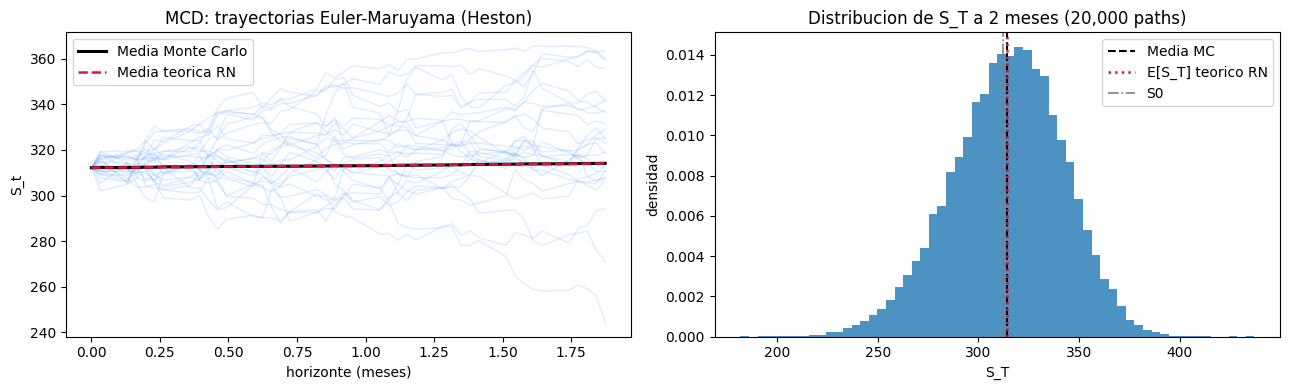

In [80]:
t_grid_months = ((business_dates - business_dates[0]).days.to_numpy(dtype=np.float64) / 365.0) * 12.0

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

if S_paths is not None:
    ax[0].plot(t_grid_months, S_paths[:, :25], alpha=0.22, lw=1.0, color='#6aa9ff')
ax[0].plot(t_grid_months, mc_mean_path, color='black', lw=2.2, label='Media Monte Carlo')
ax[0].plot(t_grid_months, rn_mean_path, color='crimson', lw=1.8, ls='--', label='Media teorica RN')
ax[0].set_title(f'{SYMBOL}: trayectorias Euler-Maruyama (Heston)')
ax[0].set_xlabel('horizonte (meses)')
ax[0].set_ylabel('S_t')
ax[0].legend()

ax[1].hist(S_T, bins=60, color='#1f77b4', alpha=0.80, density=True)
ax[1].axvline(np.mean(S_T), color='black', ls='--', lw=1.5, label='Media MC')
ax[1].axvline(S_theoretical_rn, color='crimson', ls=':', lw=1.8, label='E[S_T] teorico RN')
ax[1].axvline(S0, color='gray', ls='-.', lw=1.2, label='S0')
ax[1].set_title(f'Distribucion de S_T a 2 meses ({n_paths:,} paths)')
ax[1].set_xlabel('S_T')
ax[1].set_ylabel('densidad')
ax[1].legend()

fig.tight_layout()
plt.show()

## Comparacion con datos reales (close diario)

Esta celda descarga cierres diarios reales del ticker en la ventana `[start_date, end_date_target]` y los compara con la **media de Monte Carlo** en esas mismas fechas bursatiles (interseccion de fechas).

Comparacion media MC vs close real en 39 fechas:
  MAE  = 9.738191
  RMSE = 11.611593
  MAPE = 3.0165%
  Ultima fecha comparada: 2026-02-27
  Media MC final=314.168188 | Close real final=341.060000


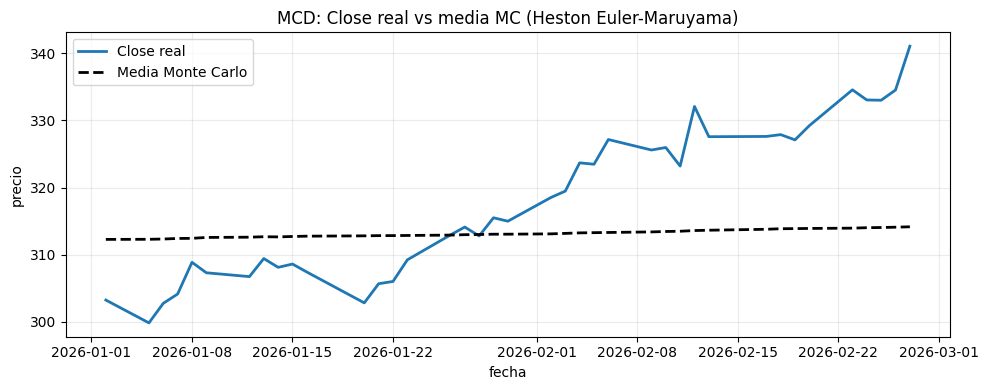

In [81]:
from io import StringIO

def fetch_stooq_daily_close(symbol: str, start_date, end_date) -> pd.DataFrame:
    ticker = f"{symbol.lower()}.us"
    url = f"https://stooq.com/q/d/l/?s={ticker}&i=d"
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    df = pd.read_csv(StringIO(resp.text))

    if not {'Date', 'Close'}.issubset(df.columns):
        raise RuntimeError('Respuesta inesperada de Stooq: faltan columnas Date/Close.')

    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
    df = df.dropna(subset=['Date', 'Close']).sort_values('Date').reset_index(drop=True)

    mask = (df['Date'] >= pd.Timestamp(start_date)) & (df['Date'] <= pd.Timestamp(end_date))
    out = df.loc[mask, ['Date', 'Close']].copy()
    return out.reset_index(drop=True)

mc_mean_df = pd.DataFrame({'Date': business_dates, 'mc_mean': mc_mean_path})

try:
    real_df = fetch_stooq_daily_close(SYMBOL, start_date, end_date_target)
except Exception as exc:
    print(f'No se pudieron descargar datos reales para {SYMBOL}: {exc}')
    real_df = pd.DataFrame(columns=['Date', 'Close'])

if real_df.empty:
    print(
        'No hay precios reales disponibles en la ventana solicitada. '
        'Puede que el horizonte sea futuro respecto al ultimo dato publicado.'
    )
else:
    comp_df = pd.merge(mc_mean_df, real_df, on='Date', how='inner')
    if comp_df.empty:
        print('No hubo interseccion de fechas entre simulacion y datos reales.')
    else:
        comp_df['abs_error'] = (comp_df['mc_mean'] - comp_df['Close']).abs()
        comp_df['sq_error'] = (comp_df['mc_mean'] - comp_df['Close']) ** 2
        comp_df['ape_pct'] = 100.0 * comp_df['abs_error'] / comp_df['Close'].replace(0.0, np.nan)

        mae = float(comp_df['abs_error'].mean())
        rmse = float(np.sqrt(comp_df['sq_error'].mean()))
        mape = float(comp_df['ape_pct'].mean(skipna=True))

        print(f'Comparacion media MC vs close real en {len(comp_df)} fechas:')
        print(f'  MAE  = {mae:.6f}')
        print(f'  RMSE = {rmse:.6f}')
        print(f'  MAPE = {mape:.4f}%')
        print(f'  Ultima fecha comparada: {comp_df["Date"].iloc[-1].date()}')
        print(f'  Media MC final={comp_df["mc_mean"].iloc[-1]:.6f} | Close real final={comp_df["Close"].iloc[-1]:.6f}')

        fig, ax = plt.subplots(1, 1, figsize=(10, 4))
        ax.plot(comp_df['Date'], comp_df['Close'], color='#1f77b4', lw=2.0, label='Close real')
        ax.plot(comp_df['Date'], comp_df['mc_mean'], color='black', lw=2.0, ls='--', label='Media Monte Carlo')
        ax.set_title(f'{SYMBOL}: Close real vs media MC (Heston Euler-Maruyama)')
        ax.set_xlabel('fecha')
        ax.set_ylabel('precio')
        ax.legend()
        ax.grid(alpha=0.25)
        fig.tight_layout()
        plt.show()

        comp_df.head(10)